In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [19]:
df = pd.read_csv('C:/Uner/Semester 4/Data Mining I/Week 6/carEvaluation.csv')

Accuracy: 0.97
Precision: 0.98
Recall: 0.97
F1 Score: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.92      0.94        83
           1       0.62      0.91      0.74        11
           2       1.00      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.90      0.94      0.91       346
weighted avg       0.98      0.97      0.98       346

|--- doors <= 0.50
|   |--- class: 2
|--- doors >  0.50
|   |--- lug_boot <= 0.50
|   |   |--- price <= 2.50
|   |   |   |--- price <= 0.50
|   |   |   |   |--- buying <= 2.50
|   |   |   |   |   |--- maint <= 0.50
|   |   |   |   |   |   |--- persons <= 1.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- persons >  1.50
|   |   |   |   |   |   |   |--- doors <= 1.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- doors > 

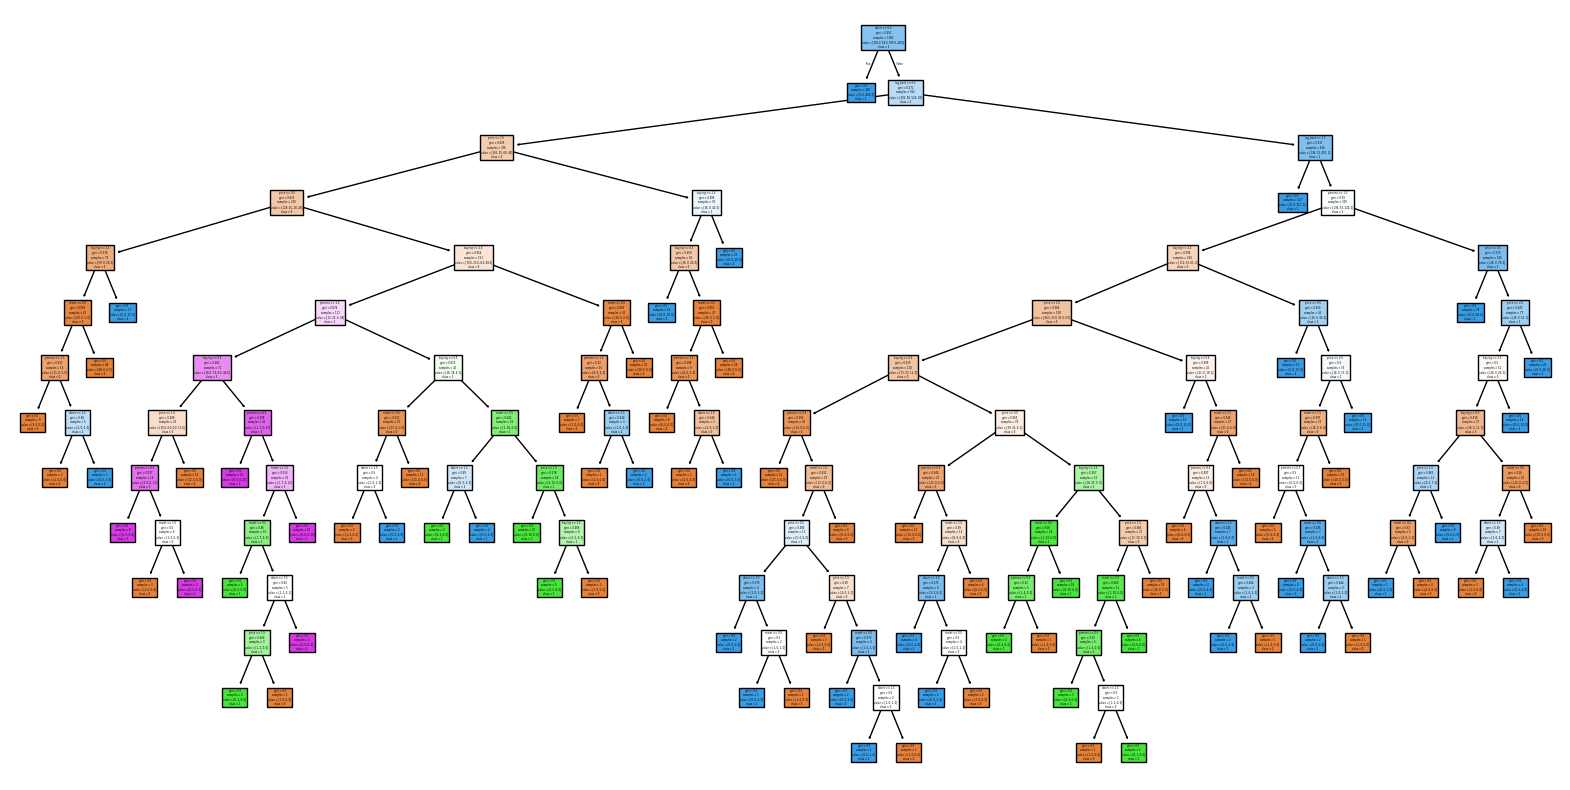

In [20]:
# Encode categorical features
label_encoders = {}
for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Split data into features and target
X = df.iloc[:, :-1]  # Semua kolom kecuali yang terakhir
y = df.iloc[:, -1]    # Kolom target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree model
clf = DecisionTreeClassifier(criterion='gini', random_state=42)  # Menggunakan CART
clf.fit(X_train, y_train)

# Evaluate model
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# Display tree structure
tree_rules = export_text(clf, feature_names=list(X.columns))
print(tree_rules)

# Plot decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=[str(i) for i in set(y)], filled=True)
plt.show()
